#Project 1: Stock Price Simulator

##Step 1: Stock Price Simulation

In [1]:
import numpy as np

###Parameters

In [2]:
initial_price = 100
days = 252
daily_return = 0.0005
daily_volatility = 0.02

###Random daily returns

In [3]:
np.random.seed(42)

In [4]:
random_returns = np.random.normal(
    daily_return,
    daily_volatility,
    days
)

###Calculate stock prices

In [6]:
prices = initial_price * np.cumprod(1 + random_returns)

###Add initial price

In [7]:
prices = np.insert(prices, 0, initial_price)

###Results

In [8]:
total_return = (prices[-1] / prices[0] - 1) * 100

In [9]:
average_return = np.mean(random_returns) * 100

In [10]:
volatility = np.std(random_returns) * 100

In [29]:
print("======================================")
print("----- STOCK PRICE SIMULATOR -----")
print("======================================")

print(f"Initial Price       : ${prices[0]:.2f}")
print(f"Final Price         : ${prices[-1]:.2f}")
print(f"Maximum Price       : ${np.max(prices):.2f}")
print(f"Minimum Price       : ${np.min(prices):.2f}")

print(f"\nTotal Return        : {total_return:.2f}%")
print(f"Average Daily Return: {average_return:.4f}%")
print(f"Daily Volatility    : {volatility:.4f}%")

----- STOCK PRICE SIMULATOR -----
Initial Price       : $100.00
Final Price         : $106.21
Maximum Price       : $113.05
Minimum Price       : $79.04

Total Return        : 6.21%
Average Daily Return: 0.0425%
Daily Volatility    : 1.9306%


##Step 2: Investment & Portfolio Simulation

###Add Investment

In [12]:
initial_investment = 10000

###Number of shares purchased

In [16]:
shares = initial_investment / initial_price

###Final portfolio value

In [17]:
final_value = shares * prices[-1]

###Profit or Loss

In [18]:
profit_loss = final_value - initial_investment

###Portfolio return

In [20]:
portfolio_return = (profit_loss / initial_investment) * 100


###Results

In [21]:
print("======================================")
print("       STOCK PORTFOLIO SIMULATOR")
print("======================================")

print(f"Initial Stock Price  : ${initial_price:.2f}")
print(f"Final Stock Price    : ${prices[-1]:.2f}")

print(f"\nInitial Investment   : ${initial_investment:.2f}")
print(f"Shares Purchased     : {shares:.2f}")

print(f"\nFinal Portfolio Value: ${final_value:.2f}")
print(f"Profit / Loss        : ${profit_loss:.2f}")
print(f"Portfolio Return     : {portfolio_return:.2f}%")

       STOCK PORTFOLIO SIMULATOR
Initial Stock Price  : $100.00
Final Stock Price    : $106.21

Initial Investment   : $10000.00
Shares Purchased     : 100.00

Final Portfolio Value: $10620.81
Profit / Loss        : $620.81
Portfolio Return     : 6.21%


##Step 3: Risk Analysis

###Maximum Drawdown

####Calculate running maximum price

In [22]:
running_max = np.maximum.accumulate(prices)

####Calculate drawdown

In [23]:
drawdown = (prices - running_max) / running_max

####Maximum drawdown

In [24]:
max_drawdown = np.min(drawdown) * 100

###Sharpe Ratio

In [25]:
sharpe_ratio = (
    np.mean(random_returns) / np.std(random_returns)
) * np.sqrt(252)


###Value at Risk (VaR)

In [26]:
var_95 = np.percentile(random_returns, 5) * 100
# 95% Value at Risk

###Best & Worst Trading Day

In [27]:
best_day = np.max(random_returns) * 100
worst_day = np.min(random_returns) * 100

###Results

In [28]:
print("======================================")
print("\n--- RISK ANALYSIS ---")
print("======================================")

print(f"Maximum Drawdown    : {max_drawdown:.2f}%")
print(f"Sharpe Ratio        : {sharpe_ratio:.2f}")
print(f"95% VaR             : {var_95:.2f}%")
print(f"Best Trading Day    : {best_day:.2f}%")
print(f"Worst Trading Day   : {worst_day:.2f}%")


--- RISK ANALYSIS ---
Maximum Drawdown    : -27.99%
Sharpe Ratio        : 0.35
95% VaR             : -2.94%
Best Trading Day    : 7.76%
Worst Trading Day   : -5.19%


##Step 4: Monte Carlo Stock & Portfolio Simulator

###Number of simulations

In [30]:
num_simulations = 1000

###Parameter

In [31]:
days = 252
initial_price = 100
daily_return = 0.0005
daily_volatility = 0.02
initial_investment = 10000

###Generate Random Returns

In [32]:
np.random.seed(42)

In [33]:
random_returns = np.random.normal(
    daily_return,
    daily_volatility,
    (num_simulations, days)
)

In [34]:
print(random_returns.shape)

(1000, 252)


###Calculate Stock Prices

In [35]:
price_paths = initial_price * np.cumprod(
    1 + random_returns,
    axis=1
)

In [36]:
print(price_paths.shape)

(1000, 252)


###Get Final Prices

In [37]:
final_prices = price_paths[:, -1]

In [38]:
print(final_prices.shape)

(1000,)


###Calculate Portfolio Values

In [39]:
shares = initial_investment / initial_price

In [40]:
final_portfolio_values = shares * final_prices

###Calculate Average Outcome

In [41]:
average_value = np.mean(final_portfolio_values)

In [48]:
median_value = np.median(final_portfolio_values)

In [42]:
best_value = np.max(final_portfolio_values)
worst_value = np.min(final_portfolio_values)

###Probability of Profit

####In how many simulations did the investor make money?

In [43]:
profitable_simulations = np.sum(
    final_portfolio_values > initial_investment
)

In [44]:
probability_of_profit = (
    profitable_simulations / num_simulations
) * 100

###Probability of Loss

In [45]:
loss_simulations = np.sum(
    final_portfolio_values < initial_investment
)

In [46]:
probability_of_loss = (
    loss_simulations / num_simulations
) * 100

###Results

In [49]:
print("==========================================")
print("       MONTE CARLO STOCK SIMULATOR")
print("==========================================")

print(f"\nNumber of Simulations : {num_simulations}")
print(f"Trading Days           : {days}")

print("\n--- PORTFOLIO RESULTS ---")

print(
    f"Initial Investment     : "
    f"${initial_investment:.2f}"
)

print(
    f"Average Final Value    : "
    f"${average_value:.2f}"
)

print(
    f"Median Final Value     : "
    f"${median_value:.2f}"
)

print(
    f"Best Final Value       : "
    f"${best_value:.2f}"
)

print(
    f"Worst Final Value      : "
    f"${worst_value:.2f}"
)

print("\n--- PROBABILITY ANALYSIS ---")

print(
    f"Profitable Simulations : "
    f"{profitable_simulations}"
)

print(
    f"Loss Simulations       : "
    f"{loss_simulations}"
)

print(
    f"Probability of Profit  : "
    f"{probability_of_profit:.2f}%"
)

print(
    f"Probability of Loss    : "
    f"{probability_of_loss:.2f}%"
)

       MONTE CARLO STOCK SIMULATOR

Number of Simulations : 1000
Trading Days           : 252

--- PORTFOLIO RESULTS ---
Initial Investment     : $10000.00
Average Final Value    : $11326.91
Median Final Value     : $10921.05
Best Final Value       : $25967.81
Worst Final Value      : $3887.48

--- PROBABILITY ANALYSIS ---
Profitable Simulations : 610
Loss Simulations       : 390
Probability of Profit  : 61.00%
Probability of Loss    : 39.00%


##Step 5: Visualization

In [50]:
import numpy as np
import matplotlib.pyplot as plt

###Plot Stock Price Paths

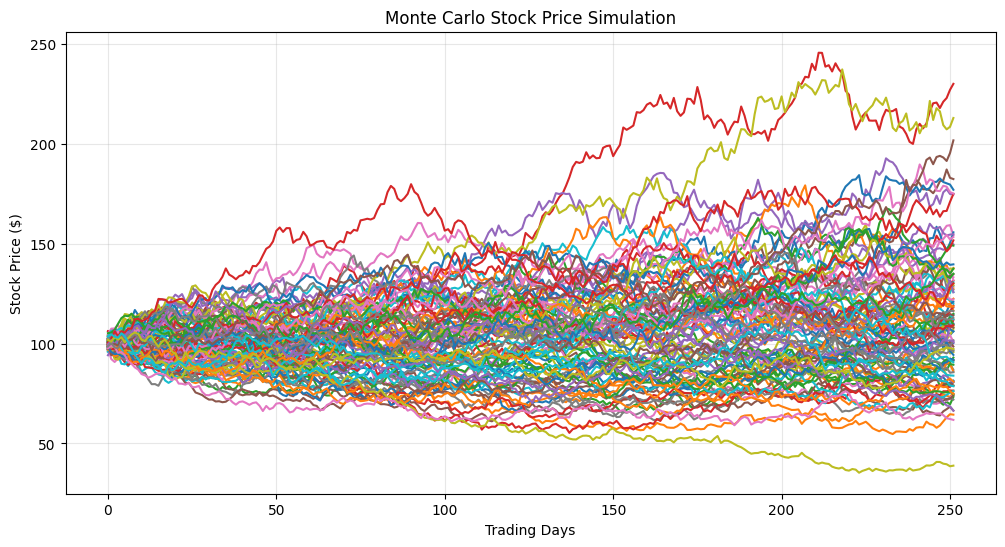

In [51]:
plt.figure(figsize=(12, 6))

for i in range(100):
    plt.plot(price_paths[i])

plt.title("Monte Carlo Stock Price Simulation")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")

plt.grid(True, alpha=0.3)

plt.show()

###Final Portfolio Value Distribution

1. Add Initial Investment Line
2. Add Mean and Median

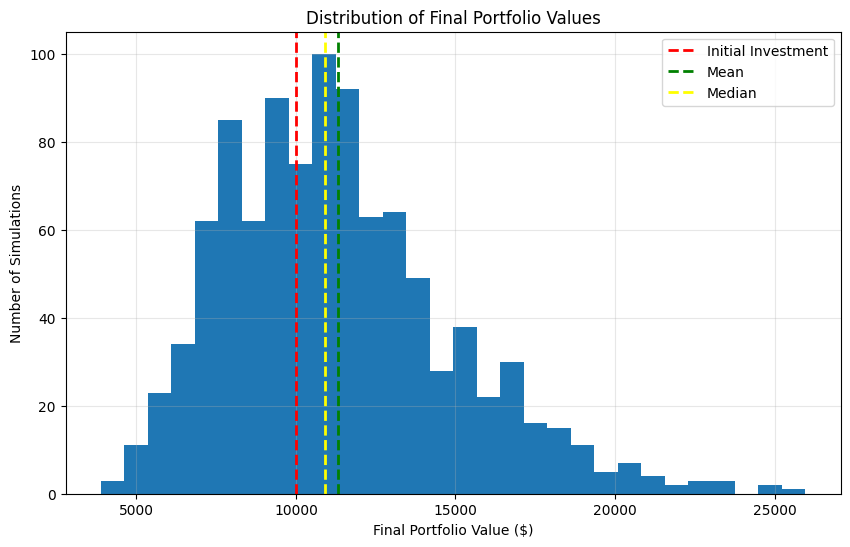

In [55]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_portfolio_values,
    bins=30
)

plt.axvline(
    initial_investment,
    linestyle="--",
    linewidth=2,
    label="Initial Investment",
    color = "red"
)

plt.axvline(
    average_value,
    linestyle="--",
    linewidth=2,
    label="Mean",
    color = "green"
)

plt.axvline(
    median_value,
    linestyle="--",
    linewidth=2,
    label="Median",
    color = "yellow"
)

plt.title("Distribution of Final Portfolio Values")

plt.xlabel("Final Portfolio Value ($)")
plt.ylabel("Number of Simulations")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

##Step 6: Confidence/Percentile Analysis

###Calculate percentiles

In [56]:
percentile_5 = np.percentile(
    final_portfolio_values,
    5
)

In [57]:
percentile_25 = np.percentile(
    final_portfolio_values,
    25
)

In [58]:
percentile_50 = np.percentile(
    final_portfolio_values,
    50
)

In [59]:
percentile_75 = np.percentile(
    final_portfolio_values,
    75
)

In [60]:
percentile_95 = np.percentile(
    final_portfolio_values,
    95
)

###Results

In [64]:
print("====================================")
print("--- PERCENTILE ANALYSIS ---")
print("====================================")

print(f"5th Percentile  : ${percentile_5:.2f}")
print(f"25th Percentile : ${percentile_25:.2f}")
print(f"50th Percentile : ${percentile_50:.2f}")
print(f"75th Percentile : ${percentile_75:.2f}")
print(f"95th Percentile : ${percentile_95:.2f}")

--- PERCENTILE ANALYSIS ---
5th Percentile  : $6395.82
25th Percentile : $8657.42
50th Percentile : $10921.05
75th Percentile : $13312.98
95th Percentile : $18080.52


###Create Scenario Analysis

In [72]:
print("====================================")
print("--- SCENARIO ANALYSIS ---")
print("====================================")

print(
    f"Downside Scenario  : ${percentile_5:.2f}"
)

print(
    f"Lower Scenario     : ${percentile_25:.2f}"
)

print(
    f"Median Scenario    : ${percentile_50:.2f}"
)

print(
    f"Upper Scenario     : ${percentile_75:.2f}"
)

print(
    f"Upside Scenario    : ${percentile_95:.2f}"
)

--- SCENARIO ANALYSIS ---
Downside Scenario  : $6395.82
Lower Scenario     : $8657.42
Median Scenario    : $10921.05
Upper Scenario     : $13312.98
Upside Scenario    : $18080.52


###Calculate Scenario Returns

In [66]:
return_5 = (
    (percentile_5 - initial_investment)
    / initial_investment
) * 100

In [67]:
return_25 = (
    (percentile_25 - initial_investment)
    / initial_investment
) * 100

In [68]:
return_50 = (
    (percentile_50 - initial_investment)
    / initial_investment
) * 100

In [69]:
return_75 = (
    (percentile_75 - initial_investment)
    / initial_investment
) * 100

In [70]:
return_95 = (
    (percentile_95 - initial_investment)
    / initial_investment
) * 100

###Results

In [71]:
print("====================================")
print("--- SCENARIO RETURNS ---")
print("====================================")

print(f"5th Percentile Return  : {return_5:.2f}%")
print(f"25th Percentile Return : {return_25:.2f}%")
print(f"50th Percentile Return : {return_50:.2f}%")
print(f"75th Percentile Return : {return_75:.2f}%")
print(f"95th Percentile Return : {return_95:.2f}%")

--- SCENARIO RETURNS ---
5th Percentile Return  : -36.04%
25th Percentile Return : -13.43%
50th Percentile Return : 9.21%
75th Percentile Return : 33.13%
95th Percentile Return : 80.81%
